# Dynamic Pricing with DQN

End-to-end model-free RL pipeline on the Uber Dynamic Pricing dataset.

| | |
|---|---|
| **Algorithm** | Double Dueling DQN |
| **State** | 11 ride-request features (normalized) |
| **Actions** | 5 price multipliers: `0.8×, 1.0×, 1.2×, 1.5×, 2.0×` |
| **Reward** | Accepted → adjusted price; Rejected → −50% attempted price |
| **Dataset** | `data/raw/dynamic_pricing_synth.csv` (10 000 rides for demo) |

**Sections**
1. Setup & Preprocessing
2. Pricing Environment
3. Q-Network + Agent
4. Training
5. Training Curves
6. Policy Evaluation
7. Action Heatmap
8. Save checkpoint

## 1. Setup & Preprocessing

In [11]:
import os, random
from collections import deque
from dataclasses import dataclass
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import MinMaxScaler
import joblib

PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), "../.."))
RAW_PATH      = os.path.join(PROJECT_ROOT, "data/raw/dynamic_pricing_synth.csv")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data/processed")

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

PyTorch : 2.10.0+cu128
Device  : CPU


In [12]:
# ── Encoding maps ──────────────────────────────────────────────────────────
LOCATION_MAP = {"Urban": 0, "Suburban": 1, "Rural": 2}
LOYALTY_MAP  = {"Regular": 0, "Silver": 1, "Gold": 2}
TIME_MAP     = {"Morning": 0, "Afternoon": 1, "Evening": 2, "Night": 3}
VEHICLE_MAP  = {"Economy": 0, "Premium": 1}

STATE_COLS = [
    "Number_of_Riders", "Number_of_Drivers",
    "demand_supply_ratio", "is_surge",
    "Location_Category", "Customer_Loyalty_Status",
    "Number_of_Past_Rides", "Average_Ratings",
    "Time_of_Booking", "Vehicle_Type",
    "Expected_Ride_Duration",
]

def preprocess(df: pd.DataFrame, scaler=None):
    df = df.copy()
    df["Location_Category"]      = df["Location_Category"].map(LOCATION_MAP)
    df["Customer_Loyalty_Status"] = df["Customer_Loyalty_Status"].map(LOYALTY_MAP)
    df["Time_of_Booking"]         = df["Time_of_Booking"].map(TIME_MAP)
    df["Vehicle_Type"]            = df["Vehicle_Type"].map(VEHICLE_MAP)
    df["demand_supply_ratio"] = df["Number_of_Riders"] / (df["Number_of_Drivers"] + 1e-6)
    df["is_surge"] = (df["demand_supply_ratio"] > df["demand_supply_ratio"].median()).astype(int)
    if scaler is None:
        scaler = MinMaxScaler().fit(df[STATE_COLS])
    X = scaler.transform(df[STATE_COLS])
    y = df["Historical_Cost_of_Ride"].values
    return X, y, scaler, df

df_raw = pd.read_csv(RAW_PATH)
# Use 10k samples for faster demo (dataset has 21k total)
df_raw = df_raw.sample(n=min(10000, len(df_raw)), random_state=42)
X, y, scaler, df_enc = preprocess(df_raw)

print(f"Dataset : {df_raw.shape}")
print(f"X shape : {X.shape}")
print(f"y range : [{y.min():.1f}, {y.max():.1f}]")
df_raw.head(3)

Dataset : (10000, 10)
X shape : (10000, 11)
y range : [26.0, 836.1]


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
2312,45,11,Rural,Gold,46,4.28,Morning,Premium,149,511.806059
16845,66,42,Urban,Gold,74,4.97,Evening,Premium,132,471.773303
6105,88,8,Rural,Gold,82,3.54,Night,Premium,1,25.993449


## 2. Pricing Environment

In [13]:
PRICE_MULTIPLIERS = np.array([0.8, 1.0, 1.2, 1.5, 2.0], dtype=np.float32)
N_ACTIONS = len(PRICE_MULTIPLIERS)

# State vector indices
IDX_DSR     = 2   # demand_supply_ratio
IDX_LOYALTY = 5
IDX_VEHICLE = 9

class PricingEnv(gym.Env):
    """Each episode = one full pass over all rides (shuffled)."""
    metadata = {"render_modes": []}

    def __init__(self, X, y, seed=42):
        super().__init__()
        self.X, self.y = X.astype(np.float32), y.astype(np.float32)
        self.n_samples = len(X)
        self._rng = np.random.default_rng(seed)
        self.observation_space = spaces.Box(0.0, 1.0, shape=(X.shape[1],), dtype=np.float32)
        self.action_space      = spaces.Discrete(N_ACTIONS)
        self._order  = np.arange(self.n_samples)
        self._cursor = 0

    def _demand_factor(self, state, multiplier):
        dsr     = float(state[IDX_DSR])
        loyalty = float(state[IDX_LOYALTY])
        vehicle = float(state[IDX_VEHICLE])
        elasticity = 0.35 * (1 - 0.4*dsr) * (1 - 0.2*loyalty) * (1 - 0.1*vehicle)
        return float(np.clip(0.85 - elasticity * (multiplier - 1.0), 0.0, 1.0))

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self._order  = self._rng.permutation(self.n_samples)
        self._cursor = 0
        return self.X[self._order[0]], {}

    def step(self, action):
        idx        = self._order[self._cursor]
        base_cost  = float(self.y[idx])
        multiplier = float(PRICE_MULTIPLIERS[action])
        adj_price  = base_cost * multiplier
        accepted   = self._rng.random() < self._demand_factor(self.X[idx], multiplier)
        
        # FIXED: Multi-objective reward balancing revenue and customer acceptance
        if accepted:
            reward = adj_price  # Full revenue if accepted
        else:
            # Penalty scales with attempted price to discourage aggressive overpricing
            reward = -adj_price * 0.5  # Lose 50% of attempted price on rejection

        self._cursor += 1
        terminated = self._cursor >= self.n_samples
        next_obs   = (
            self.X[self._order[self._cursor]] if not terminated
            else np.zeros(self.observation_space.shape, dtype=np.float32)
        )
        return next_obs, float(reward), terminated, False, {
            "base_cost": base_cost, "multiplier": multiplier,
            "adjusted_price": adj_price, "accepted": accepted,
        }

    def render(self): pass

env = PricingEnv(X, y, seed=42)
print(f"Obs : {env.observation_space}")
print(f"Act : {env.action_space}  →  {PRICE_MULTIPLIERS}")

Obs : Box(0.0, 1.0, (11,), float32)
Act : Discrete(5)  →  [0.8 1.  1.2 1.5 2. ]


## 3. Q-Network & Agent

In [14]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden_dim=128, dueling=True):
        super().__init__()
        self.dueling = dueling
        self.encoder = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        if dueling:
            self.value_head     = nn.Sequential(nn.Linear(hidden_dim,64), nn.ReLU(), nn.Linear(64,1))
            self.advantage_head = nn.Sequential(nn.Linear(hidden_dim,64), nn.ReLU(), nn.Linear(64,n_actions))
        else:
            self.q_head = nn.Sequential(nn.Linear(hidden_dim,64), nn.ReLU(), nn.Linear(64,n_actions))

    def forward(self, x):
        h = self.encoder(x)
        if self.dueling:
            V = self.value_head(h)
            A = self.advantage_head(h)
            return V + (A - A.mean(dim=1, keepdim=True))
        return self.q_head(h)


@dataclass
class Transition:
    state: np.ndarray; action: int; reward: float
    next_state: np.ndarray; done: bool

class ReplayBuffer:
    def __init__(self, capacity=20_000):
        self.buffer = deque(maxlen=capacity)
    def push(self, *args): self.buffer.append(Transition(*args))
    def sample(self, n): return random.sample(self.buffer, n)
    def __len__(self): return len(self.buffer)


class DQNAgent:
    def __init__(
        self, state_dim, n_actions, hidden_dim=128, lr=1e-3, gamma=0.99,
        epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.997,
        batch_size=64, buffer_capacity=20_000, target_update_freq=200,
        dueling=True, device="auto",
    ):
        self.device = torch.device("cuda" if (device=="auto" and torch.cuda.is_available()) else "cpu")
        self.n_actions, self.gamma = n_actions, gamma
        self.batch_size, self.target_update_freq = batch_size, target_update_freq

        self.online_net = QNetwork(state_dim, n_actions, hidden_dim, dueling).to(self.device)
        self.target_net = QNetwork(state_dim, n_actions, hidden_dim, dueling).to(self.device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.loss_fn   = nn.SmoothL1Loss()
        self.buffer    = ReplayBuffer(buffer_capacity)

        self.epsilon       = epsilon_start
        self.epsilon_end   = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.steps_done    = 0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            return int(self.online_net(s).argmax(1).item())

    def push(self, *args): self.buffer.push(*args)

    def learn(self):
        if len(self.buffer) < self.batch_size: return None
        batch       = self.buffer.sample(self.batch_size)
        states      = torch.tensor(np.array([t.state      for t in batch]), dtype=torch.float32, device=self.device)
        actions     = torch.tensor([t.action              for t in batch], dtype=torch.long,    device=self.device)
        rewards     = torch.tensor([t.reward              for t in batch], dtype=torch.float32, device=self.device)
        next_states = torch.tensor(np.array([t.next_state for t in batch]), dtype=torch.float32, device=self.device)
        dones       = torch.tensor([t.done                for t in batch], dtype=torch.float32, device=self.device)

        q_values = self.online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            best_a  = self.online_net(next_states).argmax(1)
            next_q  = self.target_net(next_states).gather(1, best_a.unsqueeze(1)).squeeze(1)
            targets = rewards + self.gamma * next_q * (1 - dones)

        loss = self.loss_fn(q_values, targets)
        self.optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), 10.0)
        self.optimizer.step()

        self.steps_done += 1
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
        if self.steps_done % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())
        return float(loss.item())

    def save(self, path):
        torch.save({"online_net": self.online_net.state_dict(),
                    "target_net": self.target_net.state_dict(),
                    "optimizer":  self.optimizer.state_dict(),
                    "epsilon": self.epsilon, "steps_done": self.steps_done}, path)
        print(f"Saved → {path}")

    def load(self, path):
        ckpt = torch.load(path, map_location=self.device)
        self.online_net.load_state_dict(ckpt["online_net"])
        self.target_net.load_state_dict(ckpt["target_net"])
        self.optimizer.load_state_dict(ckpt["optimizer"])
        self.epsilon = ckpt["epsilon"]; self.steps_done = ckpt["steps_done"]
        print(f"Loaded ← {path}")


STATE_DIM = X.shape[1]
agent = DQNAgent(state_dim=STATE_DIM, n_actions=N_ACTIONS)
print(f"Device : {agent.device}")
print(f"Params : {sum(p.numel() for p in agent.online_net.parameters()):,}")

Device : cpu
Params : 34,950


## 4. Training

In [15]:
N_EPISODES = 30  # Reduced for faster training (5-10 min)
LOG_EVERY  = 5
LEARN_EVERY = 4  # Learn every 4 steps instead of every step (4x speedup)

history = {"episode_reward": [], "episode_revenue": [], "loss": [], "epsilon": []}

for ep in range(1, N_EPISODES + 1):
    state, _ = env.reset()
    total_reward, total_revenue, losses = 0.0, 0.0, []
    done = False
    step_count = 0  # Track steps for batched learning

    while not done:
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        agent.push(state, action, reward, next_state, float(done))
        
        # Learn every LEARN_EVERY steps for 4x speedup
        step_count += 1
        if step_count % LEARN_EVERY == 0:
            loss = agent.learn()
            if loss is not None: losses.append(loss)
        
        total_reward += reward
        if info["accepted"]: total_revenue += info["adjusted_price"]
        state = next_state

    history["episode_reward"].append(total_reward)
    history["episode_revenue"].append(total_revenue)
    history["loss"].append(np.mean(losses) if losses else 0.0)
    history["epsilon"].append(agent.epsilon)

    if ep % LOG_EVERY == 0:
        print(f"Ep {ep:4d}/{N_EPISODES} | Revenue: ${total_revenue:,.1f} | "
              f"Reward: {total_reward:,.1f} | Loss: {history['loss'][-1]:.4f} | ε: {agent.epsilon:.3f}")

Ep    5/30 | Revenue: $3,965,917.6 | Reward: 2,923,354.1 | Loss: 413.1804 | ε: 0.050
Ep   10/30 | Revenue: $4,106,198.0 | Reward: 2,515,612.8 | Loss: 559.6712 | ε: 0.050
Ep   15/30 | Revenue: $3,910,490.7 | Reward: 3,071,375.5 | Loss: 403.6523 | ε: 0.050
Ep   20/30 | Revenue: $3,960,163.6 | Reward: 3,061,448.2 | Loss: 477.1189 | ε: 0.050
Ep   25/30 | Revenue: $4,240,173.1 | Reward: 2,715,565.9 | Loss: 503.4135 | ε: 0.050
Ep   30/30 | Revenue: $4,014,057.0 | Reward: 2,567,733.4 | Loss: 534.8161 | ε: 0.050


## 5. Training Curves

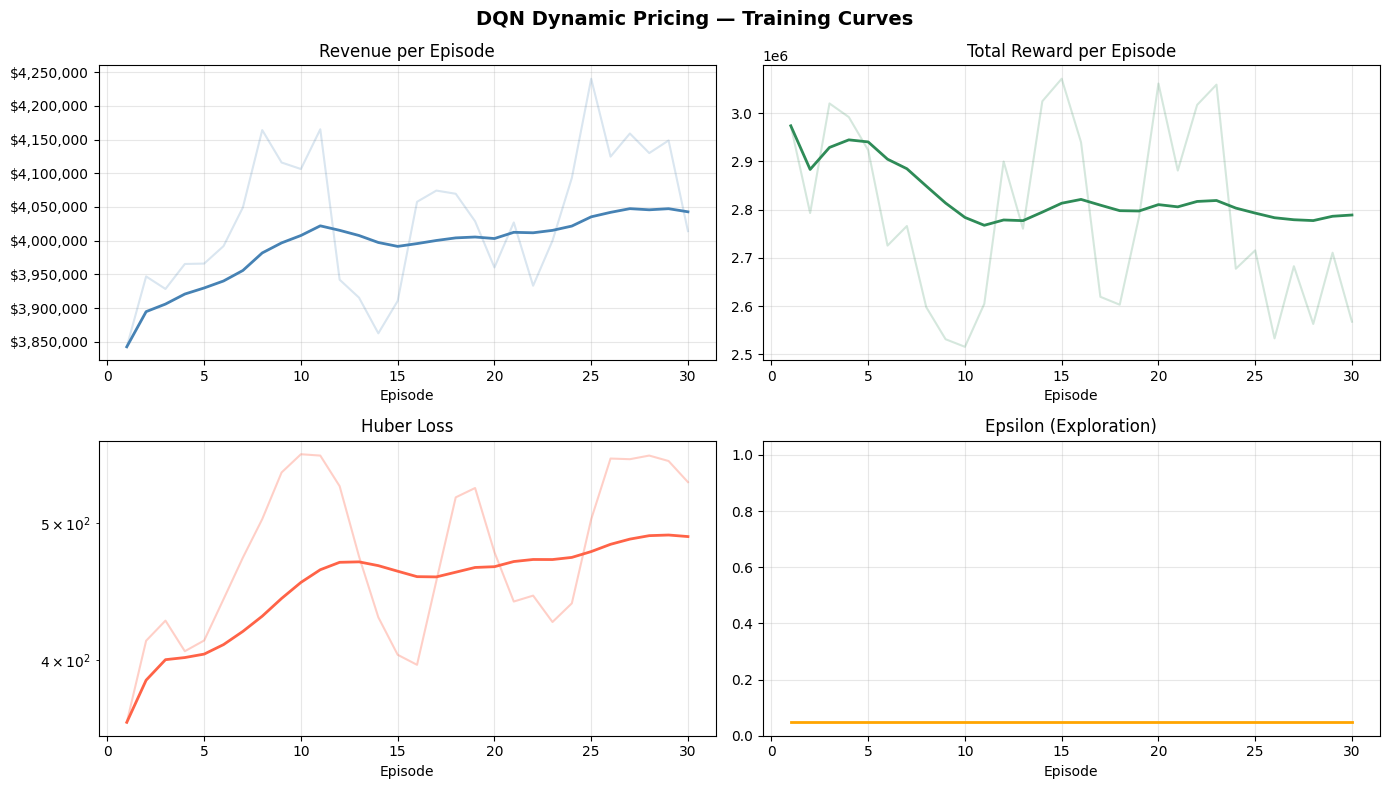

In [16]:
def smooth(x, w=20):
    return pd.Series(x).rolling(w, min_periods=1).mean().values

eps = list(range(1, N_EPISODES + 1))
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("DQN Dynamic Pricing — Training Curves", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.plot(eps, history["episode_revenue"], alpha=0.2, color="steelblue")
ax.plot(eps, smooth(history["episode_revenue"]), color="steelblue", lw=2)
ax.set_title("Revenue per Episode"); ax.set_xlabel("Episode")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}")); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(eps, history["episode_reward"], alpha=0.2, color="seagreen")
ax.plot(eps, smooth(history["episode_reward"]), color="seagreen", lw=2)
ax.set_title("Total Reward per Episode"); ax.set_xlabel("Episode"); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(eps, history["loss"], alpha=0.3, color="tomato")
ax.plot(eps, smooth(history["loss"]), color="tomato", lw=2)
ax.set_title("Huber Loss"); ax.set_xlabel("Episode")
ax.set_yscale("log"); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(eps, history["epsilon"], color="orange", lw=2)
ax.set_title("Epsilon (Exploration)"); ax.set_xlabel("Episode")
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)

plt.tight_layout()
os.makedirs(os.path.join(PROJECT_ROOT, "research/experiments"), exist_ok=True)
plt.savefig(os.path.join(PROJECT_ROOT, "research/experiments/training_curves.png"), dpi=150)
plt.show()

## 6. Policy Evaluation

In [17]:
def evaluate(env, agent, n_episodes=20, greedy=True):
    revenues, acc_rates, actions_taken = [], [], []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        ep_rev = ep_acc = 0
        ep_actions = []
        done = False
        while not done:
            if greedy:
                with torch.no_grad():
                    s = torch.tensor(obs, dtype=torch.float32, device=agent.device).unsqueeze(0)
                    a = int(agent.online_net(s).argmax(1).item())
            else:
                a = env.action_space.sample()
            obs, r, terminated, truncated, info = env.step(a)
            done = terminated or truncated
            ep_actions.append(a)
            if info["accepted"]:
                ep_rev += info["adjusted_price"]; ep_acc += 1
        revenues.append(ep_rev)
        acc_rates.append(ep_acc / env.n_samples)
        actions_taken.extend(ep_actions)
    ac = np.bincount(actions_taken, minlength=N_ACTIONS)
    return {"mean_revenue": np.mean(revenues), "std_revenue": np.std(revenues),
            "acceptance_rate": np.mean(acc_rates), "action_dist": ac / ac.sum()}

dqn_stats    = evaluate(env, agent, greedy=True)
random_stats = evaluate(env, agent, greedy=False)

print("=" * 55)
print("DQN Agent (greedy)")
print(f"  Mean Revenue    : ${dqn_stats['mean_revenue']:,.1f} ± {dqn_stats['std_revenue']:,.1f}")
print(f"  Acceptance Rate : {dqn_stats['acceptance_rate']:.1%}")
print(f"  Action Dist     : {dict(zip([f'{m}x' for m in PRICE_MULTIPLIERS], dqn_stats['action_dist'].round(3)))}")
print()
print("Random Policy")
print(f"  Mean Revenue    : ${random_stats['mean_revenue']:,.1f} ± {random_stats['std_revenue']:,.1f}")
print(f"  Acceptance Rate : {random_stats['acceptance_rate']:.1%}")
print("=" * 55)
print(f"\nRevenue lift vs random: +{(dqn_stats['mean_revenue']/random_stats['mean_revenue']-1):.1%}")

DQN Agent (greedy)
  Mean Revenue    : $3,930,192.2 ± 26,277.4
  Acceptance Rate : 70.5%
  Action Dist     : {'0.800000011920929x': np.float64(0.0), '1.0x': np.float64(0.0), '1.2000000476837158x': np.float64(0.0), '1.5x': np.float64(1.0), '2.0x': np.float64(0.0)}

Random Policy
  Mean Revenue    : $3,495,412.9 ± 21,649.2
  Acceptance Rate : 76.2%

Revenue lift vs random: +12.4%


## 7. Action Heatmap — What does the agent learn?

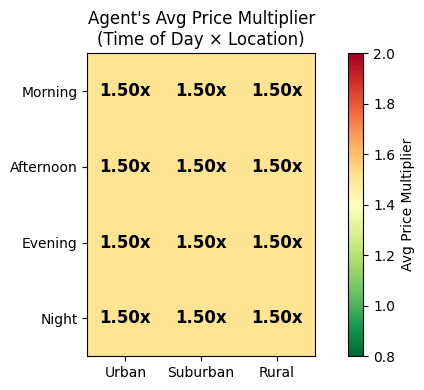

In [18]:
agent.online_net.eval()
with torch.no_grad():
    states_t = torch.tensor(X, dtype=torch.float32, device=agent.device)
    chosen   = agent.online_net(states_t).cpu().numpy().argmax(axis=1)

df_enc["chosen_multiplier"] = PRICE_MULTIPLIERS[chosen]

pivot = df_enc.groupby(["Time_of_Booking", "Location_Category"])["chosen_multiplier"].mean().unstack()
pivot.index   = ["Morning", "Afternoon", "Evening", "Night"]
pivot.columns = ["Urban", "Suburban", "Rural"]

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap="RdYlGn_r", vmin=0.8, vmax=2.0)
ax.set_xticks(range(3)); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(4)); ax.set_yticklabels(pivot.index)
for i in range(4):
    for j in range(3):
        ax.text(j, i, f"{pivot.values[i,j]:.2f}x",
                ha="center", va="center", fontsize=12, fontweight="bold")
plt.colorbar(im, ax=ax, label="Avg Price Multiplier")
ax.set_title("Agent's Avg Price Multiplier\n(Time of Day × Location)")
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "research/experiments/action_heatmap.png"), dpi=150)
plt.show()

## 8. Save Checkpoint

In [19]:
os.makedirs(PROCESSED_DIR, exist_ok=True)
CKPT = os.path.join(PROCESSED_DIR, "dqn_agent.pt")
agent.save(CKPT)

# Also save scaler for inference
joblib.dump(scaler, os.path.join(PROCESSED_DIR, "scaler.pkl"))
print("All artifacts saved.")

Saved → /home/lux/luxchar/Uber-Dynamic-Pricing/data/processed/dqn_agent.pt
All artifacts saved.
